# Self-Play Training for Q-Learning

## Why Train Against Another Learner?

Each opponent so far has a fixed behavior. The random opponent never punishes mistakes. Minimax punishes
every mistake, but always steers the game towards the same few positions, and it never makes mistakes the
agent could learn to exploit.

In **self-play**, two learning agents play against each other. As one improves, its opponent gets harder,
so the difficulty grows with the learner's skill. Both agents also see the whole range of positions, from
blunders to solid play.

| Training opponent | Pros | Cons |
|-------------------|------|------|
| **Random** | Fast, wide coverage of positions | Never punishes mistakes |
| **Minimax** | Punishes every mistake | Narrow coverage, never loses a game to learn from |
| **Another learner** | Difficulty grows with skill | Needs both agents to learn; more episodes |

Self-play is the basis of **AlphaGo/AlphaZero** (Go, chess and shogi), **OpenAI Five** (Dota 2) and
**AlphaStar** (StarCraft II).

## Setup

The reusable code lives in the `core` package, one folder up (`04_qlearning/core/`). We add that folder
to Python's import path so that `from core... import ...` works from this notebook. A fixed random seed
makes the results reproducible.

In [1]:
import sys
import random
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
random.seed(42)

## Self-Play Training

We create two independent Q-learning agents, X and O, each with its own Q-table. `play_game` updates both
of them, each at the start of its own turn and both at the end of the game.

In [2]:
from core.environment import TicTacToeEnvironment
from core.agents.q_learning_agent import QLearningAgent
from core.training import play_game


def train_selfplay(n_episodes: int = 30000, epsilon_start: float = 1.0, epsilon_end: float = 0.05,
                   epsilon_decay: float = 0.9995,
                   eval_every: int = 1000) -> tuple[QLearningAgent, QLearningAgent, dict]:
    agent_x = QLearningAgent(symbol='X', learning_rate=0.1, discount_factor=0.9, epsilon=epsilon_start)
    agent_o = QLearningAgent(symbol='O', learning_rate=0.1, discount_factor=0.9, epsilon=epsilon_start)
    env = TicTacToeEnvironment()

    history = {'x_wins': [], 'o_wins': [], 'draws': [], 'epsilon': []}
    results = {'X': 0, 'O': 0, 'draw': 0}
    epsilon = epsilon_start

    for episode in range(1, n_episodes + 1):
        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        agent_x.set_epsilon(epsilon)
        agent_o.set_epsilon(epsilon)

        results[play_game(agent_x, agent_o, env, x_starts=random.choice([True, False]))] += 1

        if episode % eval_every == 0:
            history['x_wins'].append(results['X'] / eval_every)
            history['o_wins'].append(results['O'] / eval_every)
            history['draws'].append(results['draw'] / eval_every)
            history['epsilon'].append(epsilon)
            results = {'X': 0, 'O': 0, 'draw': 0}

    return agent_x, agent_o, history

In [3]:
agent_x, agent_o, history = train_selfplay()
print(f"Agent X Q-table: {len(agent_x.q_table)} entries | Agent O Q-table: {len(agent_o.q_table)} entries")

Agent X Q-table: 10986 entries | Agent O Q-table: 10922 entries


## Visualizing Training Progress

If both agents improve together, the draw rate should rise during training. Exploration still produces
some decisive games.

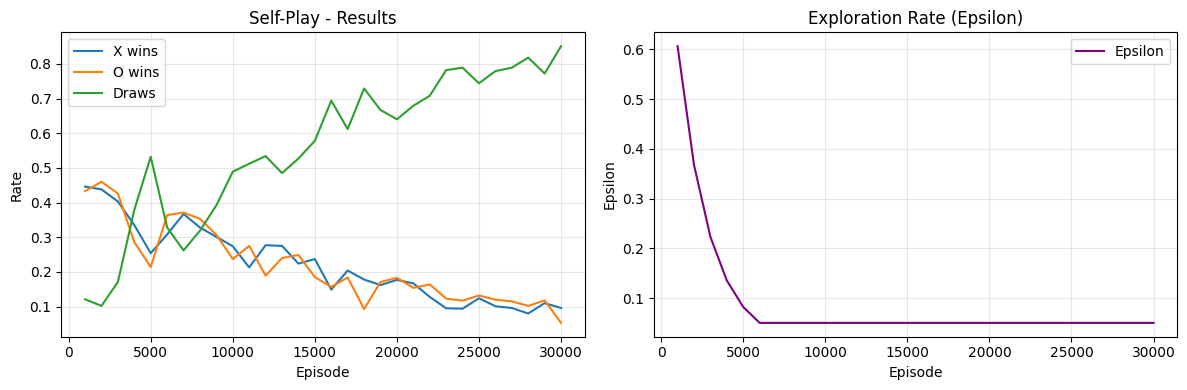

In [4]:
from core.training import plot_training_history

plot_training_history(history, eval_every=1000, title='Self-Play')

## Evaluation

Each agent is evaluated, with exploration off, against a random opponent and against Minimax.

In [5]:
from core.agents.random_agent import RandomAgent
from core.agents.minimax_agent import MinimaxAgent
from core.training import evaluate_agent

for agent, opponent_symbol in [(agent_x, 'O'), (agent_o, 'X')]:
    vs_random = evaluate_agent(agent, RandomAgent(opponent_symbol), n_games=1000)
    vs_minimax = evaluate_agent(agent, MinimaxAgent(opponent_symbol), n_games=300)
    print(f"Agent {agent.symbol}: vs Random win {vs_random['win_rate']:.1%} loss {vs_random['loss_rate']:.1%} | "
          f"vs Minimax loss {vs_minimax['loss_rate']:.1%}")

Agent X: vs Random win 94.3% loss 0.0% | vs Minimax loss 0.0%


Agent O: vs Random win 92.9% loss 0.1% | vs Minimax loss 0.0%


## Key Observations

- Both agents **never lose against Minimax** and almost never against Random (X: 0.0%, O: 0.1%), while
  winning 93-94% of the games against Random.
- Self-play combines the strengths of both earlier opponents. At the start, both players are random, which
  gives wide coverage. As they improve, each one punishes the other's mistakes, like a strong opponent.
- The cost: two separate Q-tables of about 11,000 entries each, and 30,000 episodes. Each agent only learns
  from its own side of every game.

| Training opponent | Loss vs Random | Loss vs Minimax |
|---|---|---|
| Random (notebook 02, turn-based, γ=0.9) | 2.3% | 10.8% |
| Minimax (notebook 03) | 34.0% | 0.0% |
| Another learner (this notebook) | 0.0-0.1% | 0.0% |

The next notebook makes self-play more efficient by letting both sides share what they learn.

## Exercise: Further Experiments

1. **Longer training**: train for 100,000 episodes. Does the draw rate during training keep rising?
2. **Asymmetric learners**: give agent X a higher learning rate than agent O.
3. **Curriculum**: train against a random opponent first, then switch to self-play.
4. **Tournament**: play a self-play agent against the agent from notebook 03.